# Survival Probability Profiles and Phase Spaces

This tutorial demonstrates the basic functionality of the GPSP atlas helper modules.

The examples shown below reproduce several representative figures presented in the GPSP atlas paper.

Topics covered:

- Loading a standard GPSP atlas
- Computing survival probability phase spaces
- Computing survival probability profiles as a function of energy
- Computing survival probability profiles as a function of distance
- Computing survival probability profiles $\&$ phase spaces for subluminal LIV scenarios

The examples are static and intended as reference workflows. Users should download the GPSP atlas FITS files and helper modules locally and execute the examples on their local systems.

### Imports

**Import the required Python packages and GPSP helper modules. Be sure that the GPSPAtlasHelper and GPSPLIVAtlasHelper modules are in your system path.**

In [1]:
import os
import sys

# Do not forget to edit here!
sys.path.insert(0, os.path.abspath("../../../gpsp-atlas"))

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.cm as cm

from matplotlib.colors import Normalize, LogNorm
from matplotlib.ticker import (LogLocator, NullFormatter, LogFormatterSciNotation)

from mpl_toolkits.axes_grid1 import make_axes_locatable

from gpsp_atlas_helper import GPSPAtlasHelper
from gpsp_liv_atlas_helper import GPSPLIVAtlasHelper

**The following settings are used throughout this notebook to ensure consistent figure styling.**

In [2]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
    "axes.linewidth": 1.2
})

## GPSP Atlas and Target Source Configuration

This tutorial uses the standard GPSP R12 atlas.

As an example target, we consider the Galactic Center direction:

- Galactic longitude (l): 0°
- Galactic latitude (b): 0°
- Distance (d): 8.5 kpc
- Example gamma-ray energies: 150 TeV and 2 PeV

In [6]:
atlas_file_R12 = "GPSP_Atlas_R12.fits"

# Galactic Center (l,b,d)
target_l = 0.0
target_b = 0.0
target_d = 8.5

# Example energies of 2 PeV and 150 TeV
target_e = 2e15
target_e2 = 1.5e14

atlas = GPSPAtlasHelper(atlas_file_R12)

## Survival Probability Phase Space

The GPSP atlas provides the full survival probability phase space

$P_{\rm surv}(E,D)$

for any Galactic direction.

The figure below reproduces a representative phase-space visualization similar to Figure 6 of the GPSP atlas paper.

/tmp/ipykernel_423164/3516053978.py:11: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(cs.collections, path_effects=[path_effects.withStroke(linewidth=2.5, foreground='black', alpha=0.9)])


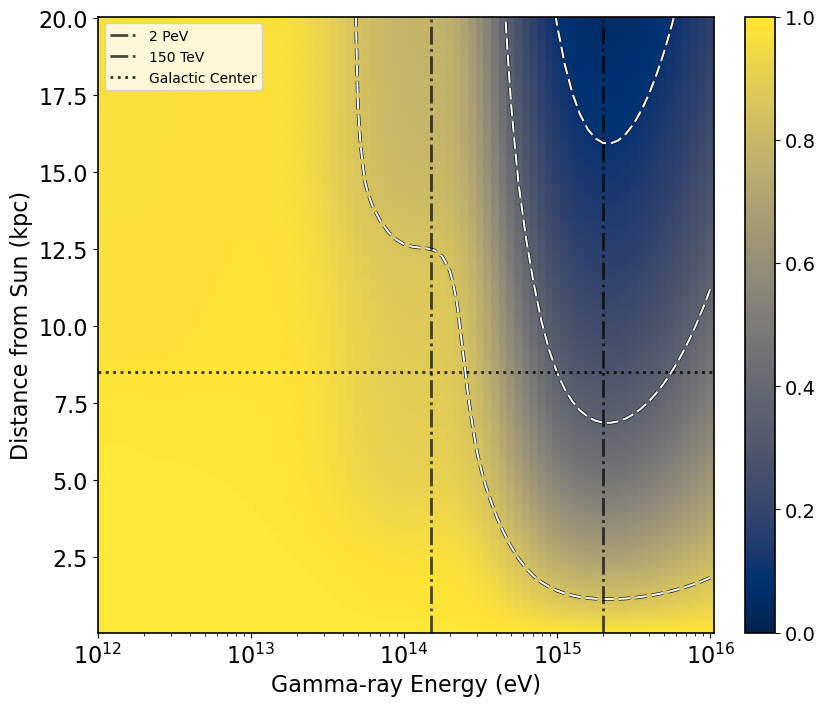

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

# This is to make sure that we have a square plot.
ax.set_box_aspect(1)

# You can directly get the survival probability phase space for the direction of (l,b) by calling the function below.
(X, Y), Z = atlas.get_2d_phase_space(target_l, target_b)

# Plot the survival phase space
im1 = ax.pcolormesh(X, Y, Z, cmap='cividis', shading='auto', norm=Normalize(0, 1.0), rasterized=True, edgecolor='face')

# Define desired survival probability contours here. levels=[0.1, 0.37, 0.85] 
cs = ax.contour(X, Y, Z, levels=[0.1, 0.37, 0.85], colors='white', linestyles='--', linewidths=1.5)

# This is for nice contour lines.
plt.setp(cs.collections, path_effects=[path_effects.withStroke(linewidth=2.5, foreground='black', alpha=0.9)])
    
ax.set_xscale('log')
ax.set_xlabel('Gamma-ray Energy (eV)')
ax.set_ylabel('Distance from Sun (kpc)')
    
ax.axvline(2e15, color='black', ls='-.', lw=2.0, alpha=0.7, label='2 PeV')
ax.axvline(1.5e14, color='black', ls='-.', lw=2.0, alpha=0.7, label='150 TeV')
ax.axhline(8.5, color='black', ls=':', lw=2.0, alpha=0.8, label='Galactic Center')
    
# Plot the color bar
cbar = fig.colorbar(im1, ax=ax, fraction=0.05, pad=0.04)

cbar.ax.tick_params(labelsize=14)
ax.legend(loc='upper left', fontsize=10)

## Survival Probability vs Energy

For a source located at a fixed distance, the helper module can directly compute the energy-dependent survival probability profile.


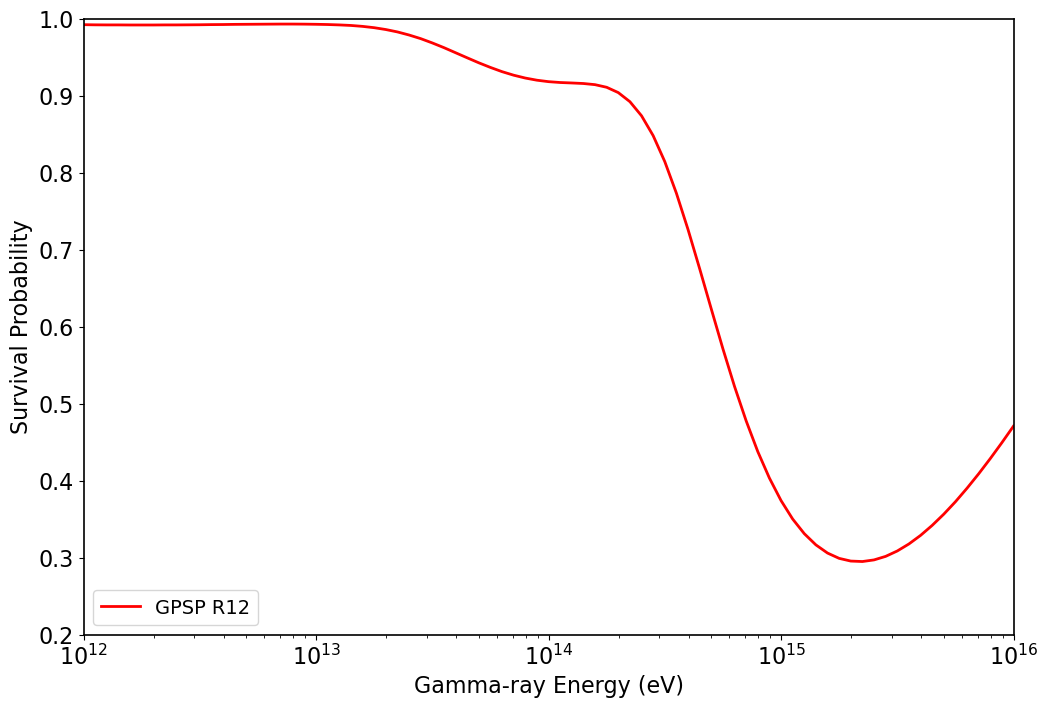

In [14]:
# You can get the survival probability profile as a function of energy for a given (l,b,d) directly as shown below.
energies, p_vs_e = atlas.get_survival_vs_energy(target_l, target_d, target_d)

fig = plt.figure(figsize=(12, 8))
plt.plot(energies, p_vs_e, color='red', lw=2.0, label='GPSP R12')
plt.xscale('log')
plt.ylim(0.2, 1.0)
plt.xlim(1e12, 1e16)
plt.xlabel('Gamma-ray Energy (eV)')
plt.ylabel('Survival Probability')
_=plt.legend(frameon=True, loc='lower left')

## Survival Probability vs Distance

For a fixed gamma-ray energy, the survival probability can be evaluated as a function of source distance.

This representation provides direct insight into Galactic gamma-ray horizons.

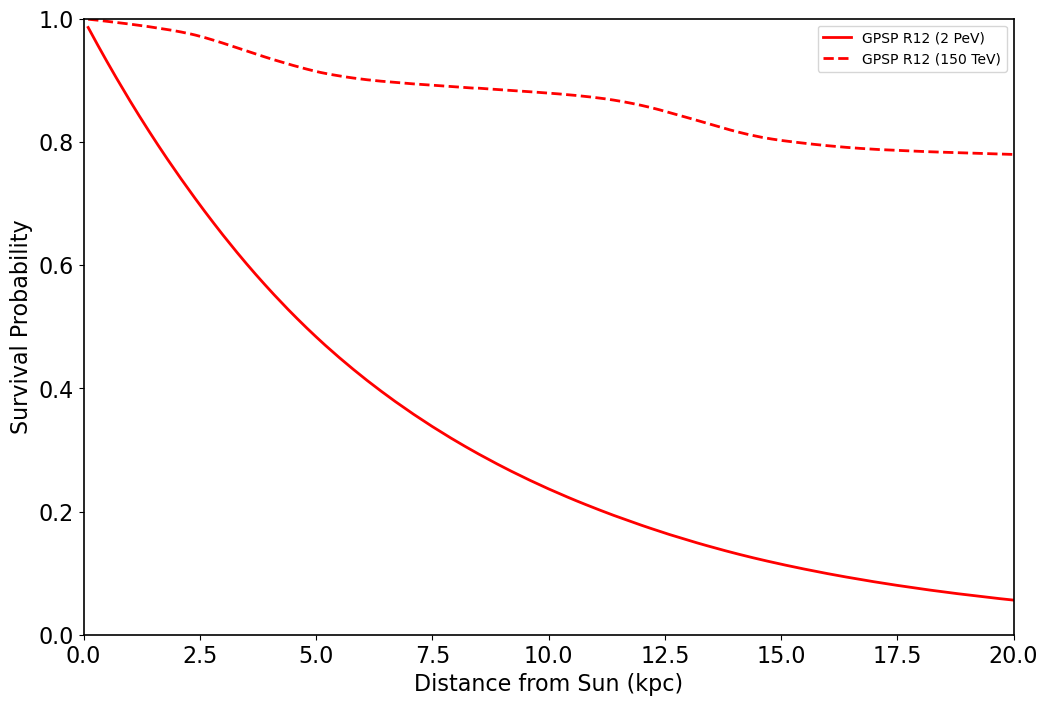

In [11]:
# You can get the survival probability profile as a function of distance for a given (l,b,E) directly as shown below.
distances, p_vs_d = atlas.get_survival_vs_distance(target_l, target_b, target_e)
distances2, p_vs_d2 = atlas.get_survival_vs_distance(target_l, target_b, target_e2)

fig = plt.figure(figsize=(12, 8))
plt.plot(distances, p_vs_d, color='red', lw=2.0, label='GPSP R12 (2 PeV)')
plt.plot(distances2, p_vs_d2, color='red', lw=2.0, label='GPSP R12 (150 TeV)', ls='--')
plt.ylim(0, 1.00)
plt.xlim(0, 20.0)    
plt.xlabel('Distance from Sun (kpc)')
plt.ylabel('Survival Probability')
_=plt.legend(frameon=True, fontsize=10)  

The attenuation increases with source distance.

The comparison between 150 TeV and 2 PeV demonstrates the strong energy dependence of Galactic gamma-ray absorption.

## LIV Survival Probability Phase Space

The GPSP-LIV atlas extends the standard atlas by including Lorentz Invariance Violation (LIV) effects.

The following example compares the survival probability phase spaces obtained in the LIV and standard scenarios.

/tmp/ipykernel_423164/968077029.py:52: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(cs_std.collections, path_effects=[path_effects.withStroke(linewidth=3, foreground='black')])
/tmp/ipykernel_423164/968077029.py:58: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(cs_liv.collections, path_effects=[path_effects.withStroke(linewidth=3, foreground='black')])


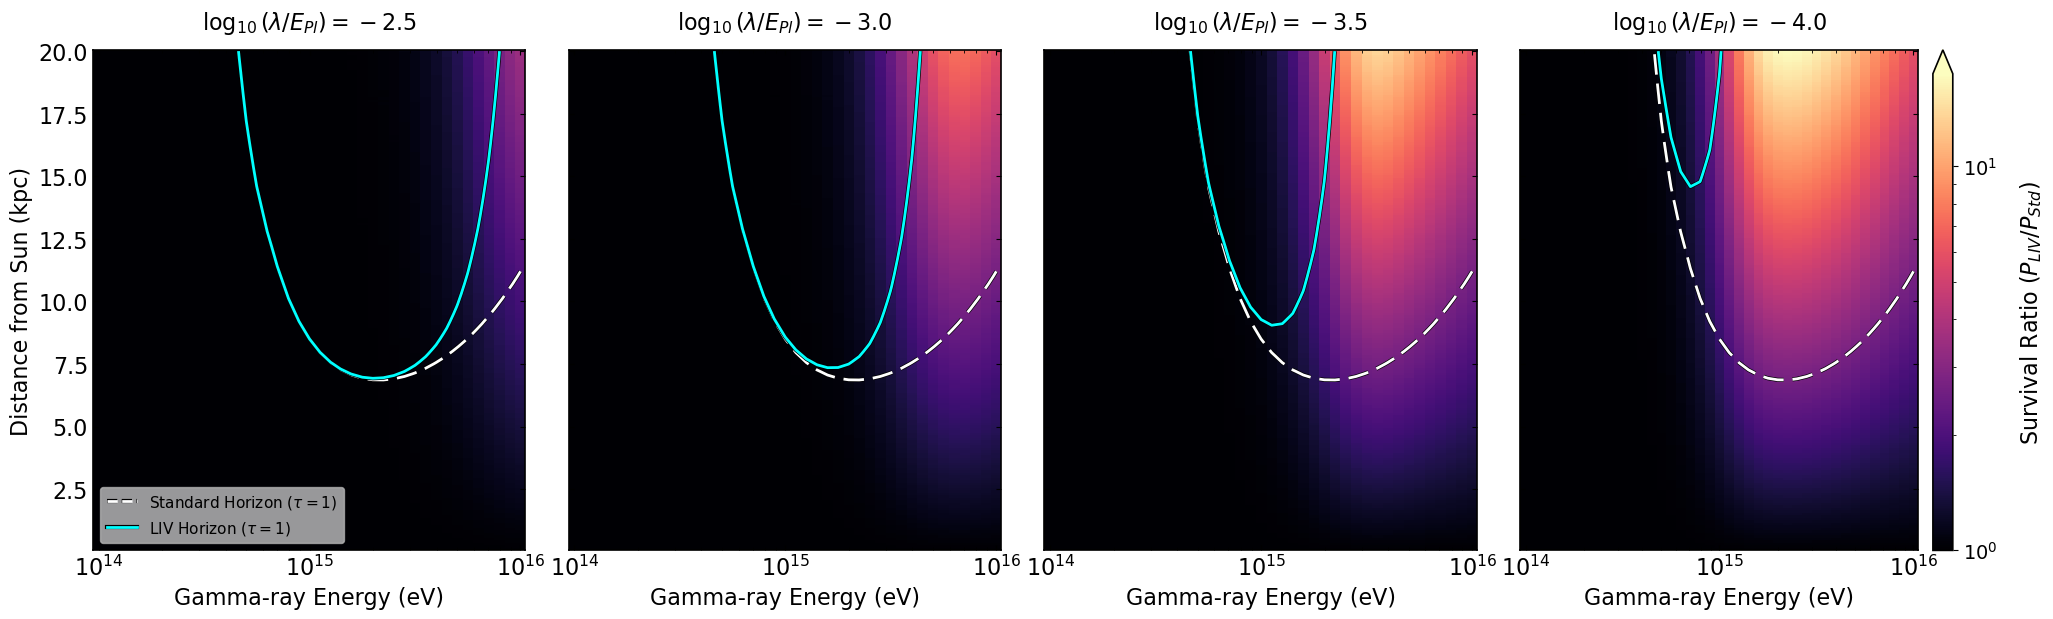

In [12]:
STD_ATLAS_FILE = "GPSP_Atlas_R12.fits"
LIV_ATLAS_FILE = "GPSP_Atlas_LIV_R12.fits"

# Modified LIV values
LAMBDA_VALUES = [-2.5, -3.0, -3.5, -4.0] 

# Read atlas files
std_atlas = GPSPAtlasHelper(STD_ATLAS_FILE)
liv_atlas = GPSPLIVAtlasHelper(LIV_ATLAS_FILE)

# Get Standard Atlas Phase Space
(X_std, Y_std), Z_std = std_atlas.get_2d_phase_space(target_l, target_b)
    
# Align the Energy Axes
# The standard atlas starts at 1 TeV. The LIV atlas starts at 100 TeV.
# We create a mask to extract only the E >= 100 TeV region from the standard data.
e_axis_std = std_atlas.e_axis
mask_e = e_axis_std >= 0.999e14  
    
# Slice the standard phase space to match LIV dimensions
Z_std_aligned = Z_std[:, mask_e]
    
# Prevent division by zero or extremely large arbitrary numbers
Z_std_safe = np.clip(Z_std_aligned, 1e-10, 1.0)

# Pre-calculate all ratios to find global_vmax
all_ratios = []
all_liv_data = []
for lam in LAMBDA_VALUES:
    (X_liv, Y_liv), Z_liv = liv_atlas.get_2d_phase_space(target_l, target_b, lam)
    all_ratios.append(Z_liv / Z_std_safe)
    all_liv_data.append(((X_liv, Y_liv), Z_liv))
    
global_vmax = max([r.max() for r in all_ratios])

fig, axes = plt.subplots(1, 4, figsize=(24, 6.5), sharey=True)
plt.subplots_adjust(wspace=0.1)

im = None

for i, lam in enumerate(LAMBDA_VALUES):
    ax = axes[i]
    ratio = all_ratios[i]
    (X_liv, Y_liv), Z_liv = all_liv_data[i]
        
    # Plot the Ratio Map Using LogNorm
    im = ax.pcolormesh(X_liv, Y_liv, ratio, shading='auto', cmap='magma', 
                        norm=LogNorm(vmin=1.0, vmax=global_vmax), rasterized=True)
        
    # Draw Standard Physics Horizon (P = 0.37) in dashed white
    cs_std = ax.contour(X_liv, Y_liv, Z_std_aligned, levels=[0.37], colors='white', 
                        linestyles='--', linewidths=2)
    plt.setp(cs_std.collections, path_effects=[path_effects.withStroke(linewidth=3, foreground='black')])
        
    # Draw LIV Physics Horizon (P = 0.37) in solid cyan
    cs_liv = ax.contour(X_liv, Y_liv, Z_liv, levels=[0.37], colors='cyan', 
                        linestyles='-', linewidths=2)
    
    plt.setp(cs_liv.collections, path_effects=[path_effects.withStroke(linewidth=3, foreground='black')])

    ax.set_xscale('log')
    ax.set_title(rf'$\log_{{10}}(\lambda/E_{{Pl}}) = {lam}$', pad=15)
    ax.set_xlabel('Gamma-ray Energy (eV)')
        
    if i == 0:
        ax.set_ylabel('Distance from Sun (kpc)')
            
    ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=12))
    ax.xaxis.set_major_formatter(LogFormatterSciNotation())
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=12))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(which='both', direction='in', top=True, right=True)

# Colorbar (Aligned with the height of the last plot) ---
divider = make_axes_locatable(axes[3])
cbar_ax = divider.append_axes("right", size="5%", pad=0.15)
    
cbar = fig.colorbar(im, cax=cbar_ax, extend='max')
cbar.set_label('Survival Ratio ($P_{LIV} / P_{Std}$)', fontsize=16, labelpad=15)
cbar.ax.tick_params(labelsize=14)

# Legend (Placed on the first panel)
axes[0].plot([], [], color='white', ls='--', lw=2, path_effects=[path_effects.withStroke(linewidth=3, foreground='black')], 
                 label='Standard Horizon ($\\tau=1$)')
axes[0].plot([], [], color='cyan', ls='-', lw=2, path_effects=[path_effects.withStroke(linewidth=3, foreground='black')], 
                 label='LIV Horizon ($\\tau=1$)')
axes[0].legend(loc='lower left', framealpha=0.6, fontsize=11)

plt.show()

### Interpretation

The color scale shows

$\frac{P_{\rm LIV}}{P_{\rm Std}}$

Values larger than unity indicate increased transparency induced by LIV effects.

The white contours represent the standard $\tau=1$ horizon, while the cyan contours show the corresponding LIV horizon.

## Survival Probability Profiles for Different LIV Scales

The GPSP-LIV atlas can be used to evaluate the survival probability profile as a function of the LIV scale parameter.

The figure below reproduces a representative example similar to Figure 11 of the GPSP atlas paper.

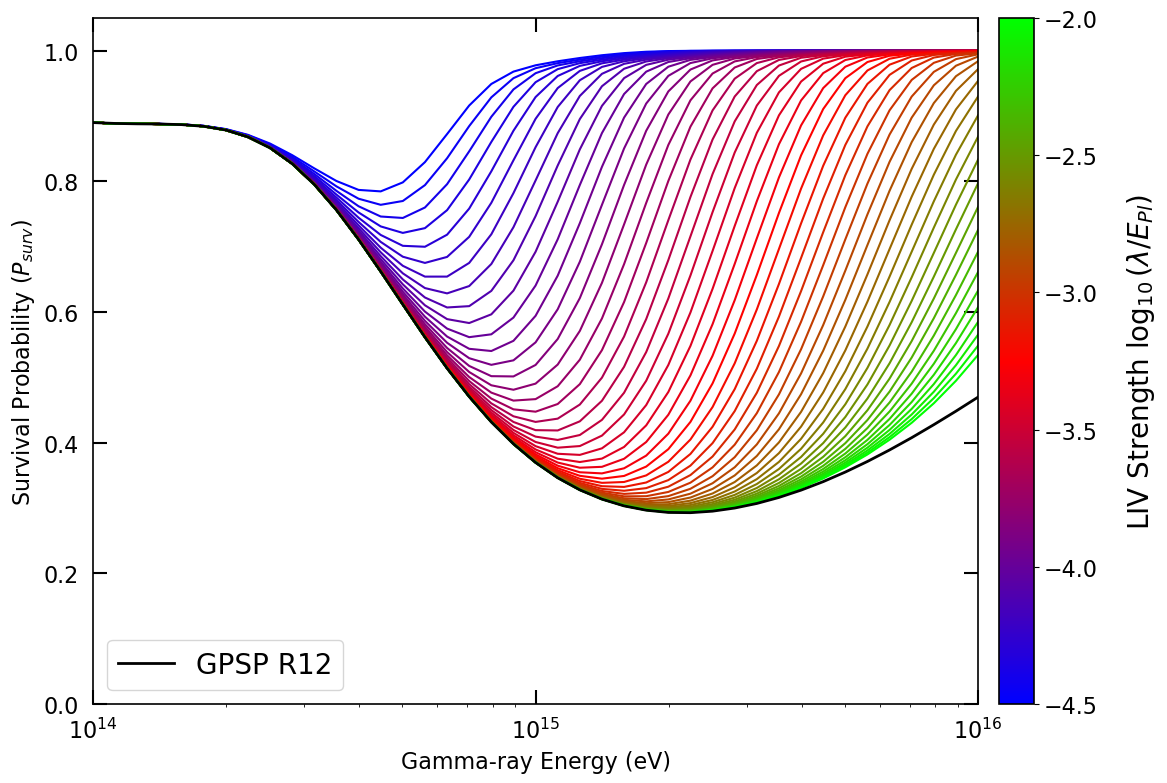

In [13]:
# Use the LIV energy axis (100 TeV to 10 PeV) for the profile
# This range is where the LIV effects are physically prominent
energies = liv_atlas.e_axis
lambda_values = liv_atlas.lam_axis
    
norm = Normalize(vmin=min(lambda_values), vmax=max(lambda_values))
colormap = cm.brg

fig, ax = plt.subplots(figsize=(12, 8))

# Plot LIV Profiles
# This loop maps the survival probability across the full LIV scale
for lam in lambda_values:
    # Interpolate probabilities at the fixed distance D
    # We use a simple 1D interp across the distance axis for the fixed energy bins
    l_idx, b_idx = liv_atlas._get_indices(target_l, target_b)
    lam_idx = liv_atlas._get_lambda_index(lam)
        
    # Shape: (n_d, n_e) -> we want the energy profile at distance D
    # Use np.interp to get the values at exactly 8.5 kpc
    p_slice = liv_atlas.data[l_idx, b_idx, :, :, lam_idx]
        
    p_at_d = []
    for e_idx in range(len(energies)):
        p_val = np.interp(target_d, liv_atlas.d_axis, p_slice[:, e_idx])
        p_at_d.append(p_val)
            
    color = colormap(norm(lam))
    ax.plot(energies, p_at_d, color=color, lw=1.5, alpha=1.0)

# Plot Standard Physics Profile
# Standard atlas spans 1 TeV to 10 PeV with 81 bins
# We slice it to match the LIV energy range for direct comparison
l_idx_s, b_idx_s = std_atlas._get_indices(target_l, target_b)
p_std_slice = std_atlas.data[l_idx_s, b_idx_s, :, :]
    
p_std_at_d = []
for e_val in energies:
    e_idx_s = np.searchsorted(std_atlas.e_axis, e_val)
    p_val = np.interp(target_d, std_atlas.d_axis, p_std_slice[:, e_idx_s])
    p_std_at_d.append(p_val)

ax.plot(energies, p_std_at_d, color='black', lw=2.0, ls='-', label='GPSP R12')

ax.set_xscale('log')
ax.set_ylim(0, 1.05)
ax.set_xlim(energies.min(), energies.max())
    
ax.set_xlabel('Gamma-ray Energy (eV)', labelpad=5)
ax.set_ylabel('Survival Probability ($P_{surv}$)', labelpad=5)

# Colorbar
sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r'LIV Strength $\log_{10}(\lambda/E_{Pl})$', fontsize=20, labelpad=20)
cbar.ax.tick_params(labelsize=16)
    
ax.legend(loc='lower left', frameon=True, fontsize=20)
    
ax.xaxis.set_major_formatter(LogFormatterSciNotation())
ax.tick_params(which='major', direction='in', top=True, right=True, length=10, width=1.5, pad=10)

plt.tight_layout()
plt.show()

## Summary

This tutorial demonstrated:

- Survival probability phase spaces
- Survival probability profiles as a function of energy
- Survival probability profiles as a function of distance
- LIV phase-space comparisons
- LIV survival probability profiles

The next tutorial focuses on producing Galactic transparency maps and gamma-ray horizon calculations.